In this notebook, the total richness of epitope-specific TCRs is estimated and metaTCRs are calculated. The Figures in Figure 2 and Supp. Figure 2 are also plotted.

In [1]:
## This notebook needs the following conda environment to run. You can create it with the following command:

# !conda env create -f environment.yml -y


## macOS/arm64 only: conda-forge ships r-inext as a broken "noarch" package containing a Linux x86-64 binary, so install iNEXT from source afterwards:

# !conda install -n tcr -c conda-forge clangxx_osx-arm64
# !conda run -n tcr R -e 'install.packages("iNEXT", repos="https://cloud.r-project.org", type="source")'

## After installation, select the tcr kernel in Jupyter

In [2]:
import ast
import colorsys
import os

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.lines as lines
import logomaker as lm


pd.set_option('display.max_columns', None)

In [3]:
%load_ext autoreload
%autoreload 2

In [ ]:
RECOMPUTE = False  # True: Recompute iNEXT and diversity metrics, False: Load from precomputed files if exist

TCR_DATABASE_PATH = './tcr_data/Supplementary table 2 TCR_data_busch_lab_ova_gp33_m45.xlsx'
VALID_MOUSE_PATH  = './analysis scripts/valid_mouse_list.csv'  # Filter some invalid mice, see 01_manuscript_figures.ipynb for details

EPITOPES = ['OVA', 'GP33', 'M45', ]
CHAINS = ['TRA', 'TRB', 'TCR', 
          'CDR3a', 'CDR3b', 'CDR3ab', 
          'metaTCRab', 'metaTCRa', 'metaTCRb']

NBOOT = 100  # number of bootstrap resamples for CI
X_LIMS = { 'OVA': 4000, 'GP33': 1500, 'M45': 700, }

RESULTS_DIR = './iNEXT_results'
os.makedirs(RESULTS_DIR, exist_ok=True)
INEXT_RESULTS_PATH = os.path.join(RESULTS_DIR, f'iNext_results_nboot={NBOOT}.csv')
DIVERSITY_RESULTS_PATH = os.path.join(RESULTS_DIR, 'diversity_metrics.csv')

In [5]:
# FIGURE CONFIGS
FIG_PATH = './manuscript_figures'

plt.rcParams["savefig.transparent"] = True

os.makedirs(FIG_PATH, exist_ok=True)
os.makedirs(FIG_PATH+'/pdf', exist_ok=True)

epitope_colors = {
    "OVA": "#1F77B4",
    "GP33": "#009E73",
    "M45": "#6A3D9A",
}

# Calculate richness and metaTCR, can be skipped if using precomputed results

In [6]:
import sys
sys.path.append("analysis scripts")

from richness_estimates import compute_inext_richness, compute_diversity_metrics
from metatcr import define_metaTCR

In [7]:
df_tcr = pd.read_excel(
    TCR_DATABASE_PATH,
    header=4, index_col=0,
)
valid_mouse = pd.read_csv(VALID_MOUSE_PATH, header=None)[0].tolist()

In [8]:
# Drop invalid mice from each TCR's mouse set, then drop TCRs left with none
valid_mouse = set(valid_mouse)
df_tcr['mouse'] = [{m for m in ast.literal_eval(s) if f'{m}_{ep}' in valid_mouse}
                   for s, ep in zip(df_tcr['mouse'], df_tcr['isolated_specificity'])]
df_tcr = df_tcr[df_tcr['mouse'].astype(bool)].reset_index(drop=True)
df_tcr['mouse'] = df_tcr['mouse'].astype(str)
df_tcr['annotated_specificity'].value_counts()

annotated_specificity
OVA     14661
GP33     8350
M45      4228
Name: count, dtype: int64

In [9]:
df_tcr['TCR'] = df_tcr['tcr_id']
df_tcr['TRA'] = df_tcr['TCR'].str.split('__').str[0]
df_tcr['TRB'] = df_tcr['TCR'].str.split('__').str[1]

df_tcr['TRAV'] = df_tcr['va']
df_tcr['TRBV'] = df_tcr['vb']
df_tcr['TRAJ'] = df_tcr['ja']
df_tcr['TRBJ'] = df_tcr['jb']

df_tcr['CDR3ab'] = df_tcr['cdr3a_aa'] + '-' + df_tcr['cdr3b_aa']
df_tcr['CDR3a'] = df_tcr['cdr3a_aa']
df_tcr['CDR3b'] = df_tcr['cdr3b_aa']

df_tcr['TRA_seq'] = df_tcr['cellranger_alpha_aa']
df_tcr['TRB_seq'] = df_tcr['cellranger_beta_aa']
df_tcr['TCR_seq'] = df_tcr['TRA_seq'] + '-' + df_tcr['TRB_seq']

##  Calculate MetaTCRs

In [10]:
df_tcr = define_metaTCR(df_tcr)

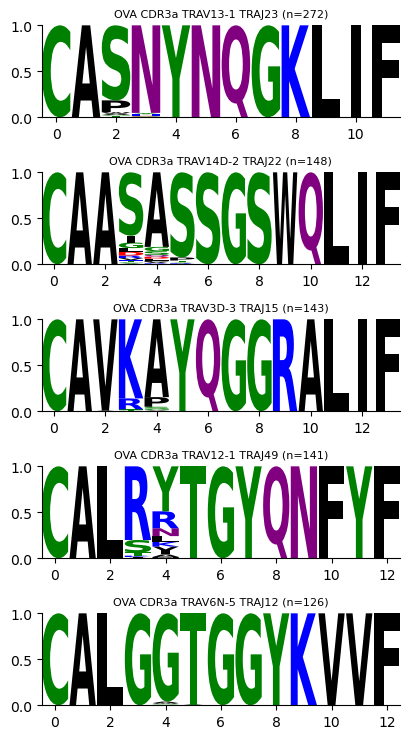

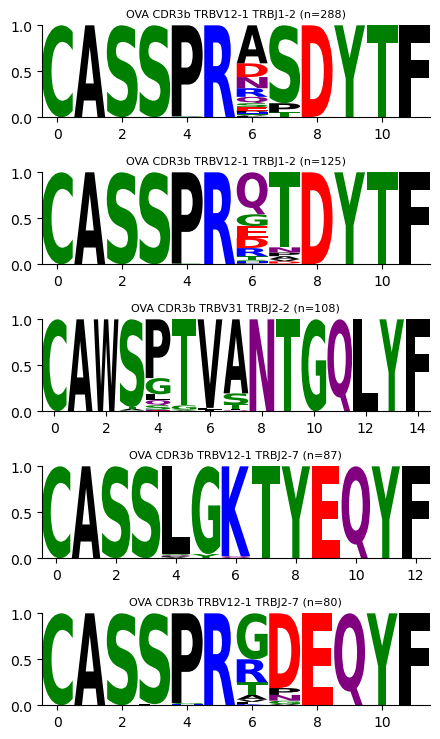

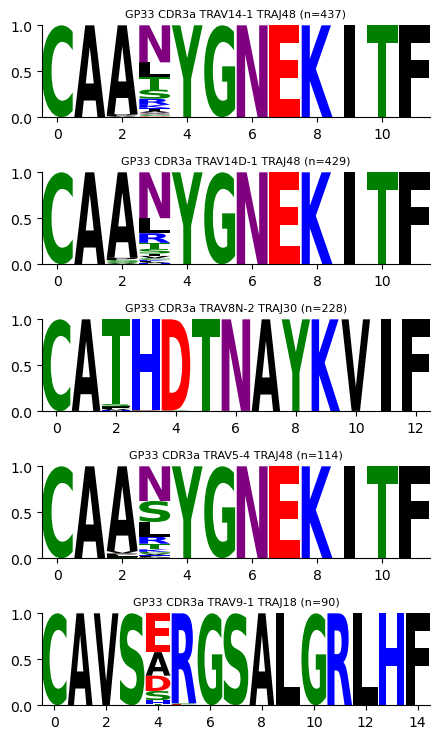

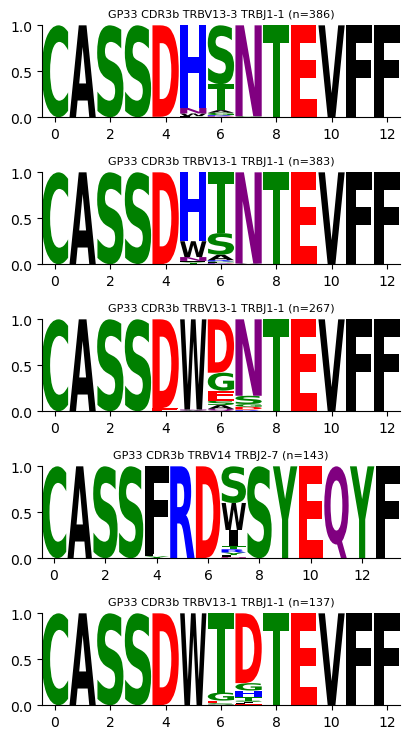

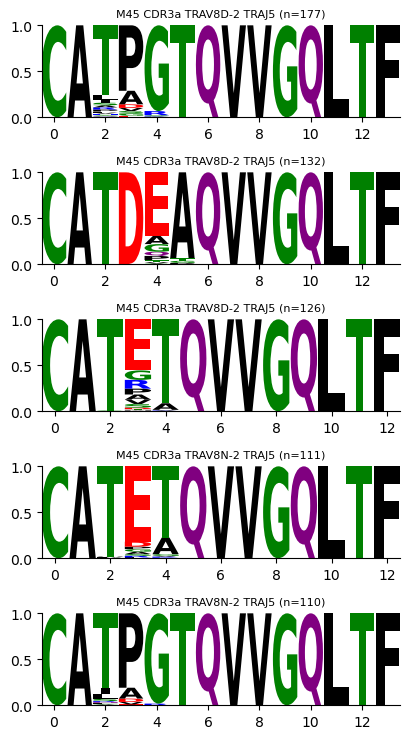

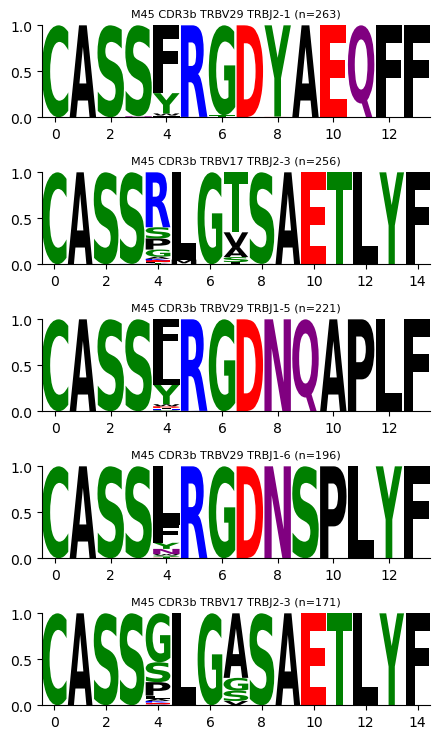

In [11]:
TOP_N = 5   # number of top meta-clonotype seeds to display

for epitope in EPITOPES:
    for cdr in ['CDR3a', 'CDR3b']:
        df_epi = df_tcr[df_tcr['annotated_specificity'] == epitope]

        v_col, j_col = {'CDR3a': ('va', 'ja'), 'CDR3b': ('vb', 'jb')}[cdr]
        group_keys = [f'metaTCR{cdr[-1]}_seed', v_col, j_col]

        top_seeds = (df_epi.groupby(group_keys)['TCR'].nunique()
                    .sort_values(ascending=False).index[:TOP_N].tolist())

        subsets = []
        for key in top_seeds:
            mask = np.ones(len(df_epi), dtype=bool)
            for col, val in zip(group_keys, key):
                mask &= (df_epi[col].values == val)
            subsets.append(df_epi[mask].drop_duplicates('TCR'))

        _w = max(3, max(s[cdr].str.len().max() for s in subsets) * 0.3)

        fig, axes = plt.subplots(len(subsets), 1, figsize=(_w, 1.5 * len(subsets)), squeeze=False)
        for i, df_sub in enumerate(subsets):
            ax = axes[i][0]
            seqs = df_sub[cdr].tolist()
            info_mat = lm.alignment_to_matrix(seqs, to_type='probability', pseudocount=0)  # bits
            lm.Logo(info_mat, ax=ax, color_scheme='chemistry')
            # With V+J grouping each meta must sit in a single V+J block.
            assert df_sub[v_col].nunique() == 1, "V+J should be unique within a meta-clonotype seed"
            assert df_sub[j_col].nunique() == 1, "V+J should be unique within a meta-clonotype seed"
            vj_str = f'{df_sub[v_col].iloc[0]} {df_sub[j_col].iloc[0]}'
            ax.set_title(f'{epitope} {cdr} {vj_str} (n={len(df_sub)})', fontsize=8)
            sns.despine(ax=ax)
        plt.tight_layout()
        plt.savefig(f'{FIG_PATH}/{"Fig2F_" if epitope == "OVA" else "SuppFig2C_"}metaTCR_Logoplots_{epitope}_{cdr}.pdf', bbox_inches='tight')

        plt.show()

## Calculate saturation with iNEXT

In [12]:
# Calculate Chao2 using iNEXT, as well as ICE and Michaelis-Menten estimates

if not os.path.exists(INEXT_RESULTS_PATH) or RECOMPUTE:
    results_all_df = compute_inext_richness(df_tcr, valid_mouse, CHAINS, X_LIMS, nboot=NBOOT)
    results_all_df.to_csv(INEXT_RESULTS_PATH, index=False)
    print(f"Completed calculation")
else:
    print(f"Cached results in `{INEXT_RESULTS_PATH}` are loaded; set `RECOMPUTE = True` to recompute.")
    results_all_df = pd.read_csv(INEXT_RESULTS_PATH)

Cached results in `./iNEXT_results/iNext_results_nboot=100.csv` are loaded; set `RECOMPUTE = True` to recompute.


In [13]:
# Calculate repertoire diversity metrics

if not os.path.exists(DIVERSITY_RESULTS_PATH) or RECOMPUTE:
    diversity_metrics = compute_diversity_metrics(df_tcr, EPITOPES, n_trials=500, subset_size=100)
    diversity_metrics.to_csv(DIVERSITY_RESULTS_PATH, index=False)
    print('Completed calcualtion')
else:
    print(f"Cached results in `{DIVERSITY_RESULTS_PATH}` are loaded; set `RECOMPUTE = True` to recompute.")
    diversity_metrics = pd.read_csv(DIVERSITY_RESULTS_PATH)

Cached results in `./iNEXT_results/diversity_metrics.csv` are loaded; set `RECOMPUTE = True` to recompute.


# Figures

In [14]:
results_all_df = pd.read_csv(INEXT_RESULTS_PATH)
diversity_metrics = pd.read_csv(DIVERSITY_RESULTS_PATH)

In [15]:
# Display estimates table

estimates_df = results_all_df[results_all_df['Method'] == 'Observed']
estimates_df = estimates_df[estimates_df['Order.q'] == 0].copy()  # Only consider q=0 for species richness
estimates_df = estimates_df.merge(diversity_metrics, 'left', ['epitope', 'chain'])
estimates_df[['Chao2', 'Chao2.LCL', 'Chao2.UCL', 'MM_estimate', 'MM.LCL', 'MM.UCL', 'ICE', 'ICE.LCL', 'ICE.UCL']] = estimates_df[['Chao2', 'Chao2.LCL', 'Chao2.UCL', 'MM_estimate', 'MM.LCL', 'MM.UCL', 'ICE', 'ICE.LCL', 'ICE.UCL']].round(0).astype(int)

display(estimates_df.drop_duplicates(['epitope', 'chain'])[['epitope', 'chain', 'Chao2', 'Chao2.LCL', 'Chao2.UCL', 'MM_estimate', 'MM.LCL', 'MM.UCL', 'ICE', 'ICE.LCL', 'ICE.UCL']].round(2).sort_values(['epitope', 'chain']))

display(estimates_df.drop_duplicates(['epitope', 'chain'])[['epitope', 'chain', 'SC', 'SC.LCL', 'SC.UCL']].round(2).sort_values(['epitope', 'chain']))



,epitope,chain,Chao2,Chao2.LCL,Chao2.UCL,MM_estimate,MM.LCL,MM.UCL,ICE,ICE.LCL,ICE.UCL
3,GP33,CDR3a,13214,12352,14076,12045,11213,12876,15527,14493,16562
5,GP33,CDR3ab,58390,55000,61781,53289,50401,56177,68779,66037,71520
4,GP33,CDR3b,13518,12683,14353,11305,10424,12186,15185,14187,16183
2,GP33,TCR,64355,60488,68223,60881,57509,64253,73431,70325,76538
0,GP33,TRA,17953,16775,19131,16223,15304,17142,20987,19859,22115
1,GP33,TRB,14843,13919,15767,12494,11473,13514,17027,15875,18179
7,GP33,metaTCRa,9930,9306,10554,9542,8929,10154,11554,10783,12324
6,GP33,metaTCRab,42851,40287,45415,36252,33757,38747,49996,47360,52631
8,GP33,metaTCRb,8458,7940,8976,6626,6148,7104,9072,8485,9658
12,M45,CDR3a,6342,5904,6780,5590,5137,6044,7655,7038,8272


,epitope,chain,SC,SC.LCL,SC.UCL
3,GP33,CDR3a,0.60,0.59,0.61
5,GP33,CDR3ab,0.30,0.29,0.31
4,GP33,CDR3b,0.62,0.60,0.63
2,GP33,TCR,0.27,0.26,0.28
0,GP33,TRA,0.53,0.52,0.55
1,GP33,TRB,0.60,0.58,0.61
7,GP33,metaTCRa,0.64,0.63,0.65
6,GP33,metaTCRab,0.39,0.38,0.40
8,GP33,metaTCRb,0.72,0.70,0.73
12,M45,CDR3a,0.69,0.68,0.70


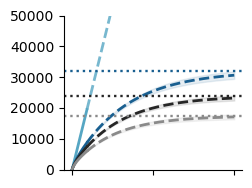

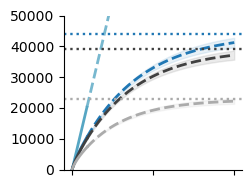

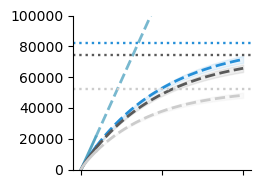

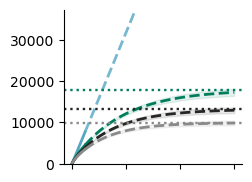

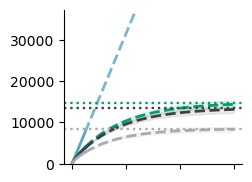

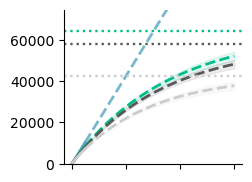

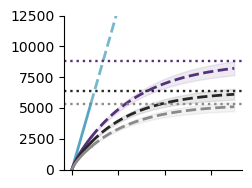

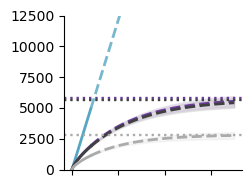

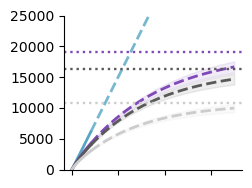

In [16]:
# iNext inter and extrapolation
def _scale_lightness(color, factor):
    """Return `color` with its HLS lightness multiplied by `factor` (>1 lighter, <1 darker)."""
    r, g, b = mcolors.to_rgb(color)
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    return mcolors.to_hex(colorsys.hls_to_rgb(h, max(0.0, min(1.0, l * factor)), s))

# brightness factor applied to the epitope colour, per chain position
_EPI_BRIGHTNESS = {'paired': 1.20, 'beta': 1.0, 'alpha': 0.8}
# fixed grey shades (paired = brightest, alpha = darkest) — two well-separated bands
_CDR3_GREYS     = {'paired': '#595959', 'beta': '#404040', 'alpha': '#262626'}  # dark grey
_METATCR_GREYS = {'paired': '#CCCCCC', 'beta': '#ABABAB', 'alpha': '#8A8A8A'}  # light grey
lw = 2

def get_chain_colors(epitope):
    """Palette (dict keyed by chain name) for a single epitope's saturation-curve panel."""
    epi = epitope_colors[epitope]
    return {
        'TCR':        _scale_lightness(epi, _EPI_BRIGHTNESS['paired']),
        'TRB':        _scale_lightness(epi, _EPI_BRIGHTNESS['beta']),
        'TRA':        _scale_lightness(epi, _EPI_BRIGHTNESS['alpha']),
        'CDR3ab':     _CDR3_GREYS['paired'],
        'CDR3b':      _CDR3_GREYS['beta'],
        'CDR3a':      _CDR3_GREYS['alpha'],
        'metaTCRab': _METATCR_GREYS['paired'],
        'metaTCRb':  _METATCR_GREYS['beta'],
        'metaTCRa':  _METATCR_GREYS['alpha'],
        'All Private': "#56A6C3",  # Cyan
    }

# a / b -> alpha / beta greek symbols for legend labels
CHAIN_LABELS = {
    'TRA': 'TRA', 'TRB': 'TRB', 'TCR': 'TCR',
    'CDR3a': 'CDR3α', 'CDR3b': 'CDR3β', 'CDR3ab': 'CDR3αβ',
    'metaTCRa': 'mTCRα', 'metaTCRb': 'mTCRβ', 'metaTCRab': 'mTCRαβ',
    'All private': 'All private', 'All Private': 'All private',
}


def plot_sat_curve(epitope, chain):
    pal = get_chain_colors(epitope)
    df_sub = results_all_df[(results_all_df['epitope'] == epitope) & (results_all_df['chain'].isin(chain))].copy()
    
    df_sub = df_sub[df_sub['t'] <= X_LIMS[epitope]].copy()
    avg_rep_size = df_sub[df_sub['chain'] == chain[0]]['qD'].iloc()[0]
    df_sub['All private'] = df_sub['t'] * avg_rep_size
    obs = df_sub[df_sub['Method'].isin(['Rarefaction', 'Observed'])]
    extrapolated = df_sub[df_sub['Method'] == 'Extrapolation']

    sns.lineplot(obs[obs['chain'] == chain[0]], x='t', y='All private', lw=lw, color=pal['All Private'], alpha=1.0, label='All private', ls='-')
    sns.lineplot(extrapolated[extrapolated['chain'] == chain[0]], x='t', y='All private', lw=lw, color=pal['All Private'], alpha=0.8, ls='--')
    sns.lineplot(obs, x='t', y='qD', hue='chain', palette=pal, lw=lw, )
    sns.lineplot(extrapolated, x='t', y='qD', hue='chain', palette=pal, lw=lw, ls='--', alpha=1.0, legend=False)
    for c in chain:
        obs_c = obs[obs['chain'] == c]
        extrapolated_c = extrapolated[extrapolated['chain'] == c]
        plt.fill_between(obs_c['t'], obs_c['qD.LCL'], obs_c['qD.UCL'], color=pal[c], alpha=0.1)
        plt.fill_between(extrapolated_c['t'], extrapolated_c['qD.LCL'], extrapolated_c['qD.UCL'], color=pal[c], alpha=0.1)
        plt.axhline(df_sub[df_sub['chain'] == c]['Chao2'].iloc[0], color=pal[c], ls=':', alpha=1, lw=1.7)

    plt.ylim(0, 1.1 * df_sub['Chao2'].iloc[0])
    plt.xlabel('n repertoires')
    plt.ylabel(f'n unique ({epitope})')
    sns.despine()
    handles, labels = plt.gca().get_legend_handles_labels()
    labels = [CHAIN_LABELS.get(l, l) for l in labels]
    plt.legend(handles, labels, frameon=False, fontsize=7.5, bbox_to_anchor=(0.5, 1.3), loc='upper center', title='', ncol=2)


# Main figure, only TCR and metaTCR for OVA
for epitope in EPITOPES:
    for i, chain in enumerate([['TRA', 'CDR3a', 'metaTCRa'], ['TRB', 'CDR3b', 'metaTCRb'], ['TCR', 'CDR3ab', 'metaTCRab']]):
        plt.figure(figsize=(2.3, 2.0))
        plot_sat_curve(epitope, chain)
        # plt.tight_layout()
        if epitope == 'OVA' and (chain[0] in ['TRA', 'TRB']):
            plt.ylim(0, 50000)
        elif epitope == 'OVA' and (chain[0] in ['TCR']):
            plt.ylim(0, 100000)

        elif epitope == 'GP33' and (chain[0] in ['TRA', 'TRB']):
            plt.ylim(0, 37500)
        elif epitope == 'GP33' and (chain[0] in ['TCR']):
            plt.ylim(0, 75000)

        elif epitope == 'M45' and (chain[0] in ['TRA', 'TRB']):
            plt.ylim(0, 12500)
        elif epitope == 'M45' and (chain[0] in ['TCR']):
            plt.ylim(0, 25000)

        plt.gca().get_legend().remove()

        plt.xlabel('')
        plt.ylabel('')
        plt.tick_params(axis='x', labelbottom=False)

        plt.savefig(f'{FIG_PATH}/{"Fig2D_" if epitope == "OVA" else "SuppFig2D_"}Saturation_curve_{epitope}_{chain}.pdf', bbox_inches='tight')
        plt.show()


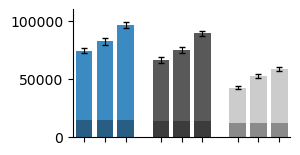

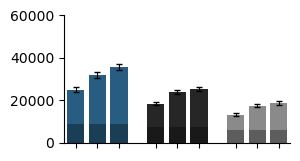

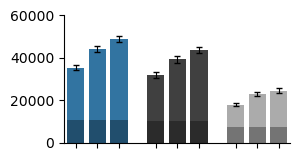

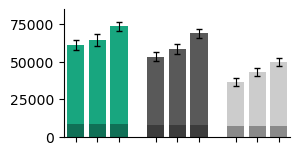

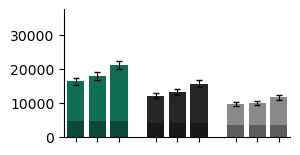

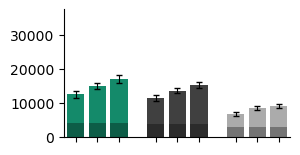

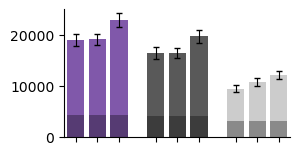

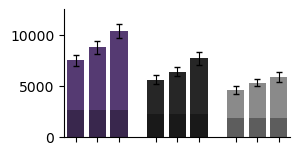

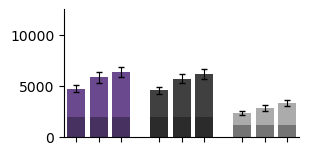

In [17]:
# Barplot showing absolute estimates with different estimators
# x tick label -> (point estimate column, lower CI column, upper CI column)
EST_COLS = {
    'MM':    ('MM_estimate', 'MM.LCL',    'MM.UCL'),
    'Chao2': ('Chao2',       'Chao2.LCL', 'Chao2.UCL'),
    'ICE':   ('ICE',         'ICE.LCL',   'ICE.UCL'),
}

for e in EPITOPES:
    pal = get_chain_colors(e)
    for chain in [['TCR', 'CDR3ab', 'metaTCRab'], ['TRA', 'CDR3a', 'metaTCRa'], ['TRB', 'CDR3b', 'metaTCRb']]:
        df_sub = estimates_df[estimates_df['epitope'] == e]
        
        df_sub = df_sub[df_sub['chain'].isin(chain)]
        subset_long = df_sub.melt(id_vars=['epitope', 'chain', 'qD'], value_vars=['MM_estimate', 'Chao2', 'ICE'], var_name='Estimator', value_name='Estimate')
        subset_long['Estimator'] = subset_long['Estimator'].str.replace('MM_estimate', 'MM')
        subset_long = subset_long.reset_index(drop=True).copy()
        
        g = sns.catplot( data=subset_long, kind="bar", x="Estimator", y="Estimate", col="chain", col_order=chain, hue="chain", hue_order=chain, palette=pal, dodge=False, height=2.2, aspect=0.5, legend=False, sharey=True )
        plt.subplots_adjust(wspace=0.2) 

        g.despine(top=True, right=True)

        all_axes = list(g.axes.flat)
        for i, ax in enumerate(all_axes):
            ax.spines['bottom'].set_visible(False)
            if i > 0:
                ax.spines['left'].set_visible(False)
                ax.tick_params(left=False, labelleft=False)
        
        for ax, chain_name in zip(g.axes.flat, chain):
            chain_data = df_sub[df_sub['chain'] == chain_name]

            if chain_data.empty:
                continue

            observed = chain_data['qD'].iloc[0]
            for bar in ax.patches:
                ax.bar(
                    x=bar.get_x() + bar.get_width() / 2,
                    height=min(observed, bar.get_height()),
                    width=bar.get_width(),
                    color='black',
                    alpha=0.32,
                    linewidth=0,
                    zorder=3
                )

        for ax, chain_name in zip(g.axes.flat, chain):
            cd = df_sub[df_sub['chain'] == chain_name]
            if cd.empty:
                continue
            xmap = {t.get_text(): x for x, t in zip(ax.get_xticks(), ax.get_xticklabels())}
            xs, est, err = [], [], [[], []]
            for label, (pcol, lcol, ucol) in EST_COLS.items():
                if label not in xmap or cd[lcol].isna().all():
                    continue
                point = cd[pcol].iloc[0]
                xs.append(xmap[label])
                est.append(point)
                err[0].append(point - cd[lcol].iloc[0])
                err[1].append(cd[ucol].iloc[0] - point)
            if xs:
                ax.errorbar(xs, est, yerr=err, fmt='none', ecolor='black',
                            elinewidth=0.8, capsize=2, zorder=4)

        left_ax = all_axes[0]
        right_ax = all_axes[-1]

        pos_left = left_ax.get_position()
        pos_right = right_ax.get_position()
        y_coord = pos_left.y0

        line = lines.Line2D( [pos_left.x0, pos_right.x1], [y_coord, y_coord], transform=g.fig.transFigure, color='black', linewidth=0.8, clip_on=False )
        g.fig.add_artist(line)

        g.set_axis_labels("", "")
        g.set_titles("") 
        g.set_xticklabels(rotation=45, ha='right')

        if e == 'OVA' and (chain[0] in ['TRA', 'TRB']):
            plt.ylim(0, 60000)
        elif e == 'OVA' and (chain[0] in ['TCR']):
            plt.ylim(0, 110000)

        elif e == 'GP33' and (chain[0] in ['TRA', 'TRB']):
            plt.ylim(0, 37500)
        elif e == 'GP33' and (chain[0] in ['TCR']):
            plt.ylim(0, 85000)

        elif e == 'M45' and (chain[0] in ['TRA', 'TRB']):
            plt.ylim(0, 12500)
        elif e == 'M45' and (chain[0] in ['TCR']):
            plt.ylim(0, 25000)

        for ax in g.axes.flat:
            ax.tick_params(axis='x', labelbottom=False)

        patches = [mpatches.Patch(color=pal[name], label=CHAIN_LABELS.get(name, name)) for name in chain]

        plt.savefig(f'{FIG_PATH}/SuppFig2E_Barplot_Estimates_{e}_{chain[0]}.pdf', bbox_inches='tight')
        plt.show()

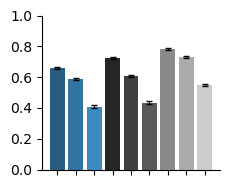

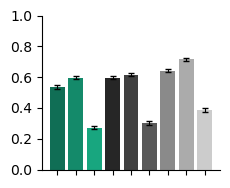

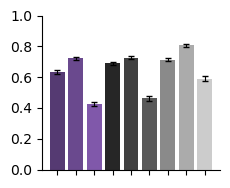

In [18]:
# Coverage bar plot

order_list = ['metaTCRa', 'CDR3a', 'TRA', 'metaTCRb', 'CDR3b', 'TRB', 'metaTCRab', 'CDR3ab', 'TCR']
order_list = [ 'TRA', 'TRB', 'TCR', 'CDR3a', 'CDR3b', 'CDR3ab', 'metaTCRa', 'metaTCRb', 'metaTCRab', ]
for e in EPITOPES:
    plt.figure(figsize=(2.3, 2.0))
    df_sub = estimates_df[estimates_df['epitope'] == e]

    pal = get_chain_colors(e)
    ax = sns.barplot(data=df_sub, x='chain', y='SC', hue='chain', order=order_list, palette=pal,)

    sc = df_sub.drop_duplicates('chain').set_index('chain').reindex(order_list)
    bars = sorted((p for p in ax.patches if p.get_height() > 0),
                  key=lambda p: p.get_x())
    xpos = [p.get_x() + p.get_width() / 2 for p in bars]
    lower = (sc['SC'] - sc['SC.LCL']).to_numpy(dtype=float)
    upper = (sc['SC.UCL'] - sc['SC']).to_numpy(dtype=float)
    ax.errorbar(x=xpos, y=sc['SC'].to_numpy(dtype=float),
                yerr=[lower, upper], fmt='none', ecolor='black', elinewidth=0.8, capsize=2)

    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels([])
    plt.xlabel("Chain")
    plt.ylabel(f"Sample Coverage ({e})")
    plt.ylim(0, 1)
    sns.despine()
    plt.xlabel('')
    plt.ylabel('')
    ax.legend_.remove() if ax.legend_ else None

    plt.savefig(f'{FIG_PATH}/SuppFig2F_Coverage_{e}.pdf', bbox_inches='tight')

    plt.show()

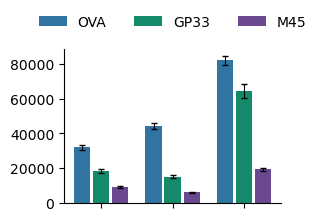

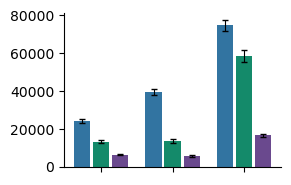

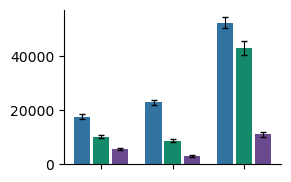

In [19]:
# Comparison between epitopes
chao2_lookup = estimates_df.drop_duplicates(['epitope', 'chain']).set_index(['epitope', 'chain'])
for order in [['TRA', 'TRB', 'TCR'], ['CDR3a', 'CDR3b', 'CDR3ab'], ['metaTCRa', 'metaTCRb', 'metaTCRab']]:
    plt.figure(figsize=(2.8, 2.))
    ax = sns.barplot(estimates_df, x='chain', y='Chao2', hue='epitope', hue_order=EPITOPES, 
                     palette=epitope_colors, order=order, gap=0.15)

    for epi, container in zip(EPITOPES, ax.containers):
        xpos, y, lower, upper = [], [], [], []
        for chain, bar in zip(order, container):
            if (epi, chain) not in chao2_lookup.index:
                continue
            row = chao2_lookup.loc[(epi, chain)]
            xpos.append(bar.get_x() + bar.get_width() / 2)
            y.append(row['Chao2'])
            lower.append(row['Chao2'] - row['Chao2.LCL'])
            upper.append(row['Chao2.UCL'] - row['Chao2'])
        ax.errorbar(x=xpos, y=y, yerr=[lower, upper], fmt='none',
                    ecolor='black', elinewidth=0.8, capsize=2)

    sns.despine()
    if order[-1] == 'TCR':
        plt.legend(frameon=False, bbox_to_anchor=(0.5, 1.3), loc='upper center', title='', ncol=3)
    else:
        plt.legend([], [], frameon=False)
    plt.ylabel(f'est. n unique (Chao2)')
    plt.xlabel('')
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels([], rotation=0, )
    plt.ylabel('')

    plt.savefig(f'{FIG_PATH}/Fig2E_Epitope_Comparison_Chao2_{order[-1]}.pdf', bbox_inches='tight')
    plt.show()

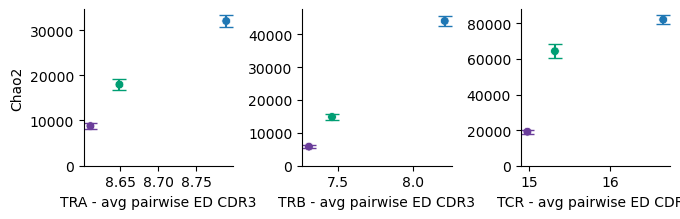

In [20]:
# Relationship between distance and Chao2 estimates
CHAINS = ['TRA', 'TRB', 'TCR', ]

metric_name_dict = {
    'avg_dist_CDR3': 'avg pairwise ED CDR3',  
}

for diversity_metric in metric_name_dict.keys():
    plt.figure(figsize=(len(CHAINS) * 2.3, 2.3))
    for i, chain in enumerate(CHAINS):
        plt.subplot(1, len(CHAINS), i+1)
        df_sub = estimates_df[estimates_df['chain'] == chain]
        x = diversity_metric
        df_sub = df_sub[df_sub['epitope'].isin(EPITOPES)].copy()

        ax = sns.scatterplot(df_sub, x=x, y='Chao2', hue='epitope', palette=epitope_colors, s=40, legend=i == len(CHAINS)+1)
        for e in EPITOPES:
            e_subset = df_sub[df_sub['epitope'] == e]
            lower_error = e_subset['Chao2'] - e_subset['Chao2.LCL']
            upper_error = e_subset['Chao2.UCL'] - e_subset['Chao2']
            plt.errorbar(x=e_subset[x].to_numpy(dtype=float), y=e_subset['Chao2'].to_numpy(dtype=float), 
                         yerr=np.vstack([lower_error.to_numpy(dtype=float), upper_error.to_numpy(dtype=float)]), 
                         fmt='none', ecolor=epitope_colors[e], capsize=5, )     
        ylim = ax.get_ylim()
        plt.ylim(0, ylim[1])
        plt.ylabel('Chao2' if i == 0 else '')
        
        plt.xlabel(f'{chain} - {metric_name_dict[diversity_metric]}')
        sns.despine()
    legend_handles = [mpatches.Patch(color=epitope_colors[e], label=e) for e in EPITOPES]

    plt.tight_layout()
    plt.savefig(f'{FIG_PATH}/SuppFig2G_distance_chao2.pdf', bbox_inches='tight')
    plt.show()